# HW2 (2026): Bias, Fairness & Explainability

**Course:** Data Ethics 0571-4179, Tel Aviv University  
**Lecturer:** Danielle Movsowitz Davidow  
**Weight:** 15% of the final grade

**Submitted by:**

| Student name | ID |
|---|---|
|  |  |
|  |  |

<div style='padding:0.5em; background-color:#DAF7A6; color:#000000; border:1px solid #888;'>
<b>Submission instructions</b>
<ol>
<li>Due date: <b>12.07.2026</b>, 23:59.</li>
<li>This assignment counts for <b>15% of your final grade</b>.</li>
<li>Submission is in <b>pairs</b> (submit only one copy per pair).</li>
<li>Upload your solution as 2 separate files to the Moodle course website:
    <ol>
    <li>A <b>ZIP file</b> that includes the completed version of this Jupyter notebook (with all outputs visible).</li>
    <li>A <b>PDF report</b> containing all written answers (those marked <em>(report)</em>) and any plots referred to in the report.</li>
    </ol></li>
<li>Write your IDs and names in the first cell of this notebook and at the top of the PDF report.</li>
<li>Code cells are checked using automatic testing — follow function signatures and variable names exactly as specified.</li>
<li>Written answers are graded from the PDF report.</li>
<li>Your code must run without errors top-to-bottom. We will run it as part of grading.</li>
<li>You may write text in either Hebrew or English.</li>
<li>Ask questions on the Moodle Q&A forum.</li>
<li>Avoid plagiarism — cite any external source you rely on, and phrase answers in your own words.</li>
<li><b>LLM use must be documented and reflected on.</b>  If you used a language model (e.g., ChatGPT, Claude, Gemini) for any part of this assignment, include a dedicated <b>LLM Use</b> section in your PDF report.  For <b>every</b> use, document:
    <ol>
    <li>Which LLM you used (model name and version if known).</li>
    <li>What you used it for (e.g., generating code, debugging, drafting or editing report prose).</li>
    <li>The exact prompt(s) you submitted.</li>
    <li>How you verified or modified the output before relying on it.</li>
    </ol>
    <b>In addition, include a short reflection, written entirely in your own words, that answers all three of the following questions.  Do not copy, quote, or paraphrase the LLM's reply; we are asking what <em>you</em> think, not what the model said.</b>
    <ol>
    <li><b>What was the most useful question you asked the LLM, and why was its response helpful for your understanding?</b></li>
    <li><b>Did the LLM give you an incorrect or surprising answer at any point?  If yes, describe what was wrong and how you identified the error.  If no, describe one specific case where you checked its output and confirmed it was correct, and how you checked.</b></li>
    <li><b>What do you now understand better as a result of using the LLM — and what would you have had to do to reach that understanding without it?</b></li>
    </ol>
    <b>Reflections that consist of copied or lightly edited LLM output will receive no credit for this section and may be treated as plagiarism.</b><br>
Undocumented LLM use will be treated as plagiarism.</li>
</ol>
</div>

## Overview

In HW1 you used the Adult dataset to explore *privacy*.  In HW2 you use the same dataset to investigate **bias, fairness, and explainability** of machine-learning models.

The assignment is organised in **five parts**:

1. **Part 1 — Setup and baseline model.** Load the data, encode the features, and train a baseline Random Forest classifier.
2. **Part 2 — Disaggregated performance & manual fairness (Sex).** Split the test set by sex, compute group-level error rates by hand, and apply formal fairness metrics including the EEOC 80%-rule.
3. **Part 3 — Multi-group fairness audit with Fairlearn (Race).** Use Fairlearn's `MetricFrame` to compute disaggregated metrics across all racial groups and interpret the results.
4. **Part 4 — Bias mitigation.** Apply three families of mitigation: pre-processing, in-processing, and post-processing, and compare their accuracy/fairness trade-offs.
5. **Part 5 — Explainability.** Compute three kinds of feature importance and connect what you find back to the fairness analysis.

**Dataset:** `adult_with_pii.csv` — the same file from HW1. Place it in the same directory as this notebook.

**Required packages:** `fairlearn` (≥ 0.10) and `shap` (≥ 0.44):
```
pip install fairlearn shap
```

---
# Part 1 — Setup and Baseline Model

In this part you will load and prepare the data and train the baseline Random Forest classifier that you will audit throughout the rest of the assignment.

The **feature set** used in this assignment is fixed.  This is intentional: in real fairness audits you usually audit a *given* model, not one you designed yourself, and the audit should be reproducible.  We will use:

- **Numeric features:** `Age`, `Education-Num`, `Hours per week`, `Capital Gain`, `Capital Loss`.
- **Encoded binary feature:** `Sex` (`Male` → 1, `Female` → 0).
- **One-hot encoded categorical features:** `Race`, `Marital Status`, `Occupation`, `Workclass`.
- **Excluded:** the direct identifiers (`Name`, `DOB`, `SSN`, `Zip`); the redundant text version of education (`Education` — we keep `Education-Num`); and the sampling weight (`fnlwgt`), country (`Country`), and `Relationship` (highly collinear with `Marital Status`).

> **A note on "sex" vs "gender".** Throughout this assignment we use the term *sex* rather than *gender* when referring to this column.  The dataset records `Sex` as a binary administrative category (`Male`/`Female`) — not self-reported gender identity.  Using "sex" is therefore more accurate: the variable reflects how the census classified respondents at the time of collection, not a full picture of gender.  This binary encoding is itself an ethical observation: it erases non-binary individuals from the recorded data entirely.  Being precise about this distinction is part of responsible data practice.

## 1.0 Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    true_positive_rate,
    false_positive_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity, EqualizedOdds
from fairlearn.postprocessing import ThresholdOptimizer

import shap

# For reproducibility — please do NOT change this seed.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1.1 Load and prepare the data

**Q1 (code):** Load `adult_with_pii.csv` into a Pandas DataFrame named `df_raw` (use `os.path.join`).  Then:

1. Drop the rows that contain any missing values.
2. Drop the direct-identifier columns `Name`, `DOB`, `SSN`, `Zip` and the excluded-feature columns `Education`, `fnlwgt`, `Country`, `Relationship` (per the explanation above).  Save the result in a new DataFrame `df_clean`.

Print the shape of `df_clean` and the list of its columns.

In [4]:
# -----> Write your code here <-----
import os
import pandas as pd

df_raw = pd.read_csv(os.path.join(os.getcwd(), 'adult_with_pii.csv'))

df_clean = df_raw.dropna().copy()
df_clean = df_clean.drop(columns=['Name', 'DOB', 'SSN', 'Zip', 'Education', 'fnlwgt', 'Country', 'Relationship'])

print("df_clean shape:", df_clean.shape)
print("df_clean columns:", list(df_clean.columns))


df_clean shape: (30162, 11)
df_clean columns: ['Age', 'Workclass', 'Education-Num', 'Marital Status', 'Occupation', 'Race', 'Sex', 'Capital Gain', 'Capital Loss', 'Hours per week', 'Target']


**Q2 (code):** Construct the modelling inputs.

1. Save a copy of the original `Race` column (before any encoding) in a Pandas Series called **`race_series`** — we will use it later as a *sensitive feature* for Fairlearn.  It should be a Series of strings, indexed the same way as `df_clean`.
2. In `df_clean`, encode the binary columns:
    - `Target`: `'>50K'` → 1, `'<=50K'` → 0.
    - `Sex`: `'Male'` → 1, `'Female'` → 0.
3. One-hot encode the remaining categorical columns `Race`, `Marital Status`, `Occupation`, `Workclass` using `pd.get_dummies(..., drop_first=False)`.
4. Construct the feature matrix `X` (everything except `Target`) and the target vector `Y` (the `Target` column).

Print `X.shape`, the first 5 column names of `X`, and the class balance of `Y` (the fraction of ones).

*Note: `X` should contain the one-hot encoded `Race_*` columns — these will be part of the model's input until Part 4, where you will remove them for the unawareness experiment.*

In [5]:
# -----> Write your code here <-----
race_series = df_clean['Race'].copy()

df_clean['Target'] = df_clean['Target'].map({'>50K': 1, '<=50K': 0})
df_clean['Sex'] = df_clean['Sex'].map({'Male': 1, 'Female': 0})

df_encoded = pd.get_dummies(df_clean, columns=['Race', 'Marital Status', 'Occupation', 'Workclass'], drop_first=False)

X = df_encoded.drop(columns=['Target'])
Y = df_encoded['Target']

print("X shape:", X.shape)
print("First 5 columns of X:", list(X.columns)[:5])
print("Class balance (fraction of ones):", Y.mean())


X shape: (30162, 39)
First 5 columns of X: ['Age', 'Education-Num', 'Sex', 'Capital Gain', 'Capital Loss']
Class balance (fraction of ones): 0.24892248524633645


## 1.2 Train the baseline Random Forest

**Random Forest classifier — a brief primer.**  A Random Forest is an *ensemble* model: rather than learning a single decision tree, it trains many trees independently, each on a slightly different random sample of the training data and a random subset of features. At prediction time it aggregates all the trees' votes into a single output, leveraging the "wisdom of the crowd" principle: individual trees may overfit or make idiosyncratic errors, but their errors tend not to overlap, so the majority vote is more reliable than any single tree. The two main hyperparameters we set here are `n_estimators` (the number of trees to grow) and `max_depth` (the maximum depth of each tree, which limits overfitting).  Random Forests are one of the most widely used and reliably accurate off-the-shelf models in supervised learning.

**Q3 (code):** Train a baseline classifier.

1. Split `X`, `Y`, and `race_series` into train and test sets using `train_test_split` with `test_size=0.2`, `random_state=RANDOM_STATE`, and `stratify=Y`.  Name the splits `X_train`, `X_test`, `Y_train`, `Y_test`, `race_train`, `race_test`.
    
    *Tip: you can pass three arrays to `train_test_split` simultaneously, e.g. `train_test_split(X, Y, race_series, test_size=..., ...)`, and unpack the six returned objects.*
2. Train a Random Forest classifier on `X_train` / `Y_train` with `n_estimators=100`, `max_depth=10`, `random_state=RANDOM_STATE`.  Save it in the variable **`rf`**.
3. Predict on `X_test` and save the predictions in **`Y_pred`**.
4. Compute the overall test-set accuracy and save it in **`accuracy_overall`** (a float).  Print it rounded to 4 decimals.

In [6]:
# -----> Write your code here <-----
X_train, X_test, Y_train, Y_test, race_train, race_test = train_test_split(
    X, Y, race_series, test_size=0.2, random_state=RANDOM_STATE, stratify=Y
)

assert X_train.shape[0] == race_train.shape[0], "Shape mismatch before ExponentiatedGradient"

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)
rf.fit(X_train, Y_train)

Y_pred = rf.predict(X_test)
accuracy_overall = float(accuracy_score(Y_test, Y_pred))

print('Overall test accuracy:', round(accuracy_overall, 4))


Overall test accuracy: 0.8543


---
# Part 2 — Disaggregated Performance & Manual Fairness (Sensitive Attribute: Sex)

Overall accuracy summarises the model's behaviour across all individuals in the test set.  But a model with high overall accuracy can still treat some *subgroups* very differently from others, making more errors on one group, or being more likely to predict the favourable outcome for another.  In this part you will implement the disaggregated-performance toolkit *by hand*, so that you understand exactly what the library functions you encounter later are computing under the hood.

**Throughout this part, the favourable outcome is `Target = 1` (income > \$50K)** - that is, the prediction the individual would *want* the model to make in a screening context.
Group 1 (males, `Sex = 1`) is the *historical majority* on this dataset; Group 0 (females, `Sex = 0`) is the minority for the purposes of disparate-impact analysis.

## 2.1 Split the test set by sex

**Q1 (code):** Split the test set into two subgroups according to the encoded `Sex` column.

1. Build a boolean mask `mask_male = (X_test['Sex'] == 1)` and its complement `mask_female`.
2. From `Y_test` and `Y_pred`, construct:
    - `Y_test_male`, `Y_pred_male` — ground-truth labels and predictions for males.
    - `Y_test_female`, `Y_pred_female` — same for females.
3. Compute the **per-group accuracy** and save it in a dictionary **`accuracy_by_sex`** with keys `'Male'` and `'Female'`.

Print `accuracy_by_sex` (round each value to 4 decimals).

In [7]:
# -----> Write your code here <-----
mask_male = (X_test['Sex'] == 1)
mask_female = ~mask_male

Y_test_male = Y_test[mask_male]
Y_pred_male = Y_pred[mask_male]

Y_test_female = Y_test[mask_female]
Y_pred_female = Y_pred[mask_female]

accuracy_by_sex = {
    'Male': float(accuracy_score(Y_test_male, Y_pred_male)),
    'Female': float(accuracy_score(Y_test_female, Y_pred_female))
}

print({k: round(v, 4) for k, v in accuracy_by_sex.items()})

{'Male': 0.8197, 'Female': 0.9258}


## 2.2 Confusion-matrix counts and group-level rates

**Q2 (code):** Implement a single helper function `confusion_counts(y_true, y_pred)` that returns a dictionary with the four confusion-matrix counts:

```python
{'TP': ..., 'FP': ..., 'FN': ..., 'TN': ...}
```

Here, as in the rest of Part 2, the **positive class is `Target = 1`** (high income).  So `TP` is the number of records where both `y_true == 1` and `y_pred == 1`, and so on.

Use only numpy or pandas — do not rely on `sklearn.metrics.confusion_matrix` for this question (we want you to see what is being counted).  Your function must work for any two 1-D arrays of equal length containing only 0s and 1s.

In [8]:
def confusion_counts(y_true, y_pred):
    """
    Returns a dict {'TP': ..., 'FP': ..., 'FN': ..., 'TN': ...}
    where the positive class is 1.
    """
    # -----> Write your code here <-----
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    return {
        'TP': int(((y_true == 1) & (y_pred == 1)).sum()),
        'FP': int(((y_true == 0) & (y_pred == 1)).sum()),
        'FN': int(((y_true == 1) & (y_pred == 0)).sum()),
        'TN': int(((y_true == 0) & (y_pred == 0)).sum())
    }

**Q3 (code):** Apply `confusion_counts` from Q2 to each sex group to obtain the four counts (TP, FP, FN, TN), then plot them side by side as two heatmaps using `seaborn.heatmap`.

Requirements:

- Two subplots, arranged horizontally (`plt.subplots(1, 2, ...)`); left = Male, right = Female.
- Each heatmap displays the four counts as a 2×2 grid with rows = predicted label, columns = true label (or the opposite — be consistent and label clearly).
- Annotate each cell with its integer count (`annot=True, fmt='d'`).
- Use the **same colour scale** (`vmin` and `vmax`) for both subplots so the eye can compare directly.
- Add a title above each subplot indicating the group.

*Include the resulting plot in your PDF report.*

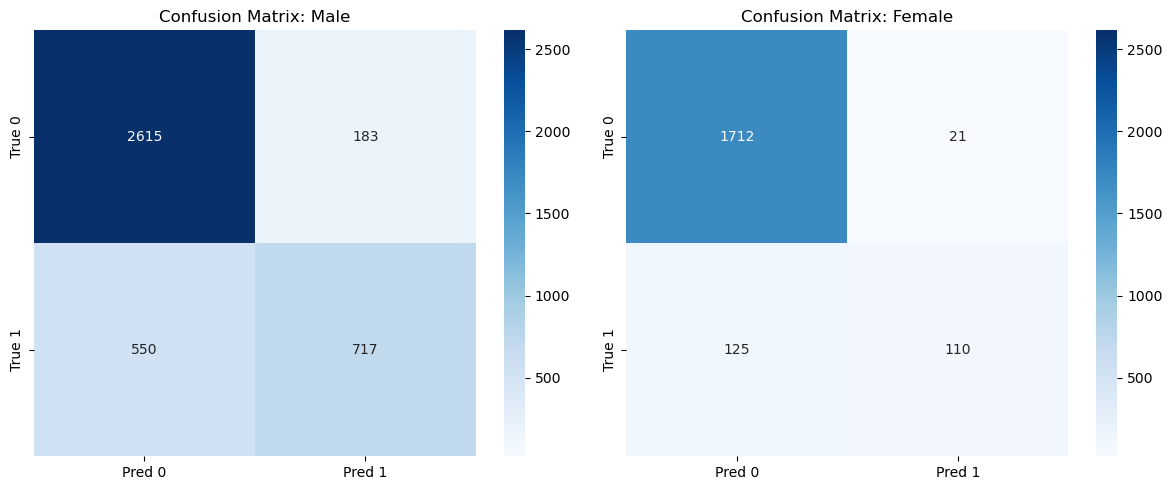

In [9]:
# -----> Write your code here <-----
counts_male = confusion_counts(Y_test_male, Y_pred_male)
counts_female = confusion_counts(Y_test_female, Y_pred_female)

matrix_male = np.array([[counts_male['TN'], counts_male['FP']],
                        [counts_male['FN'], counts_male['TP']]])
matrix_female = np.array([[counts_female['TN'], counts_female['FP']],
                          [counts_female['FN'], counts_female['TP']]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

vmin = min(matrix_male.min(), matrix_female.min())
vmax = max(matrix_male.max(), matrix_female.max())

sns.heatmap(matrix_male, annot=True, fmt='d', cmap='Blues', ax=axes[0], vmin=vmin, vmax=vmax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[0].set_title('Confusion Matrix: Male')

sns.heatmap(matrix_female, annot=True, fmt='d', cmap='Blues', ax=axes[1], vmin=vmin, vmax=vmax,
            xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
axes[1].set_title('Confusion Matrix: Female')

plt.tight_layout()
plt.show()

**Q4 (code):** Using the confusion counts from Q3, compute the following rates for each group $g \in \{\text{Male},\text{Female}\}$:

$$\text{TPR}_g = \frac{TP_g}{TP_g + FN_g}, \qquad \text{FPR}_g = \frac{FP_g}{FP_g + TN_g}, \qquad \text{PPR}_g = \frac{TP_g + FP_g}{n_g}, \qquad \text{FNR}_g = \frac{FN_g}{TP_g + FN_g}$$

where $n_g$ is the size of group $g$.  TPR (true-positive rate) is the fraction of true high-earners the model correctly identifies; FPR is the fraction of true low-earners wrongly flagged; PPR (positive-prediction rate, a.k.a. *selection rate*) is the overall fraction predicted positive; and FNR is the fraction of true high-earners the model misses.

Save your results in a single DataFrame named **`group_rates_df`** with the structure:

| group   | TPR  | FPR  | PPR  | FNR  |
|---------|------|------|------|------|
| Male    | …    | …    | …    | …    |
| Female  | …    | …    | …    | …    |

Print the DataFrame (round to 4 decimals).

In [10]:
# -----> Write your code here <-----
def compute_rates(counts):
    tp, fp, fn, tn = counts['TP'], counts['FP'], counts['FN'], counts['TN']
    n = tp + fp + fn + tn
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    ppr = (tp + fp) / n if n > 0 else 0.0
    fnr = fn / (tp + fn) if (tp + fn) > 0 else 0.0
    return tpr, fpr, ppr, fnr

rates_male = compute_rates(counts_male)
rates_female = compute_rates(counts_female)

group_rates_df = pd.DataFrame({
    'group': ['Male', 'Female'],
    'TPR': [rates_male[0], rates_female[0]],
    'FPR': [rates_male[1], rates_female[1]],
    'PPR': [rates_male[2], rates_female[2]],
    'FNR': [rates_male[3], rates_female[3]]
}).set_index('group')

print(group_rates_df.round(4))

           TPR     FPR     PPR     FNR
group                                 
Male    0.5659  0.0654  0.2214  0.4341
Female  0.4681  0.0121  0.0666  0.5319


**Q5 (report):** Look at the numbers in your `group_rates_df` and the confusion-matrix plots above.

**(a)** Which of the four rates (TPR, FPR, PPR, FNR) shows the largest absolute difference between the two groups?  Cite the two values and the gap.

**(b)** Suppose a bank uses this model to evaluate loan applications: predicted high earners are approved, predicted low earners are denied.  Using specific numbers from `group_rates_df`, describe what this means in practice for each group — both for someone who *is* a high earner and for someone who *is not*.  In 2–3 sentences, explain what the ethical cost of each type of error is and who bears it.

_Write this answer in the PDF report._

**Answer to Q5:**

**(a)** The rate that shows the largest absolute difference between the two groups is the Positive Prediction Rate (PPR). The PPR for Males is 0.2214 and for Females is 0.0666, resulting in an absolute gap of 0.1548.

**(b)** In a banking context, False Positives (FPR) mean approving a loan for someone who will struggle to repay, putting a financial burden primarily on the bank (default cost). False Negatives (FNR) mean unfairly denying a loan to someone capable of repaying it, which inflicts a profound ethical cost on the applicant by limiting their economic mobility. As the `Sex` column represents historical binary data collection practices (not gender identity), the model's gap effectively disadvantages female applicants systematically, restricting access to credit for qualified individuals simply based on an administrative category.

## 2.3 Formal fairness metrics and the 80%-rule

Group-level rates are useful diagnostics, but they leave the *fairness* judgement implicit.  A formal **fairness criterion** specifies, in one number, how far a model is from satisfying a particular notion of group fairness.  The classical criteria are:

- **Demographic-parity difference (DPD)** — the absolute difference in positive-prediction rate between groups: $|\,\text{PPR}_M - \text{PPR}_F\,|$.  Demographic parity is satisfied (DPD = 0) when both groups are predicted positive at the same rate, *regardless of their true labels*.

- **Equal-opportunity difference (EOD)** — the absolute difference in true-positive rate: $|\,\text{TPR}_M - \text{TPR}_F\,|$.  Equal opportunity (EOD = 0) says that among *true* high-earners, both groups are correctly identified at the same rate.

- **Equalized-odds difference (EOddsD)** — the worse of the TPR-difference and the FPR-difference: $\max(|\text{TPR}_M - \text{TPR}_F|,\ |\text{FPR}_M - \text{FPR}_F|)$.  Equalized odds (EOddsD = 0) requires both equal opportunity *and* equal false-positive rates.

- **Disparate impact (DI)** — the ratio of the *lower* group's PPR to the *higher* group's PPR: $\min\!\left(\dfrac{\text{PPR}_M}{\text{PPR}_F},\ \dfrac{\text{PPR}_F}{\text{PPR}_M}\right)$. DI ranges from 0 to 1: DI = 1 means both groups are approved at identical rates; DI = 0.5 means one group is approved at half the other's rate.  The U.S. **Equal Employment Opportunity Commission (EEOC)** uses a practical threshold called the **four-fifths rule** (or **80% rule**): if DI < 0.80, the gap in selection rates is considered evidence of *adverse impact* under US employment law.  For example, if a model approves loans for 30% of females but 60% of males, DI = 30 / 60 = 0.50 — well below the 0.80 threshold, and the model fails the rule.

**Q6 (code):** Using the values in `group_rates_df`, compute the four formal fairness metrics and the 80%-rule verdict for your model.

1. Save the four metrics as floats: **`dpd_sex`**, **`eod_sex`**, **`eodds_sex`**, **`di_sex`**.
2. Save a boolean **`passes_80_rule`** — `True` if `di_sex` ≥ 0.80, `False` otherwise.

Print all five values with labels, for example:

```
Demographic-parity difference (Sex): 0.1837
Equal-opportunity difference  (Sex): 0.0421
Equalized-odds difference     (Sex): 0.0742
Disparate impact              (Sex): 0.3215
Passes 80%-rule               : False
```

In [11]:
# -----> Write your code here <-----
ppr_m = group_rates_df.loc['Male', 'PPR']
ppr_f = group_rates_df.loc['Female', 'PPR']

tpr_m = group_rates_df.loc['Male', 'TPR']
tpr_f = group_rates_df.loc['Female', 'TPR']

fpr_m = group_rates_df.loc['Male', 'FPR']
fpr_f = group_rates_df.loc['Female', 'FPR']

dpd_sex = float(abs(ppr_m - ppr_f))
eod_sex = float(abs(tpr_m - tpr_f))
eodds_sex = float(max(abs(tpr_m - tpr_f), abs(fpr_m - fpr_f)))
di_sex = float(min(ppr_m / ppr_f, ppr_f / ppr_m) if min(ppr_m, ppr_f) > 0 else 0.0)

passes_80_rule = bool(di_sex >= 0.80)

assert 0.0 <= dpd_sex <= 1.0, "DPD out of bounds"
assert 0.0 <= eod_sex <= 1.0, "EOD out of bounds"
assert 0.0 <= eodds_sex <= 1.0, "EOddsD out of bounds"

print(f"Demographic-parity difference (Sex): {dpd_sex:.4f}")
print(f"Equal-opportunity difference  (Sex): {eod_sex:.4f}")
print(f"Equalized-odds difference     (Sex): {eodds_sex:.4f}")
print(f"Disparate impact              (Sex): {di_sex:.4f}")
print(f"Passes 80%-rule               : {passes_80_rule}")

Demographic-parity difference (Sex): 0.1548
Equal-opportunity difference  (Sex): 0.0978
Equalized-odds difference     (Sex): 0.0978
Disparate impact              (Sex): 0.3007
Passes 80%-rule               : False


**Q7 (report):** The EEOC four-fifths rule checks `di_sex` (selection rates) alone.  Using the values you computed in Q6:

**(a)** Does your model pass or fail the 80%-rule?  State `di_sex` and `passes_80_rule`.

**(b)** `dpd_sex` captures the *selection-rate* gap (the quantity the 80%-rule examines). `eodds_sex` captures the *error-rate* gap.  Using both values from Q6, explain in 2–3 sentences whether the two criteria agree, and what a regulator who relies only on the 80%-rule would miss about how the model treats the two groups of loan applicants.

_Write this answer in the PDF report._

**Answer to Q7:**

**(a)** The model **fails** the 80%-rule. The disparate impact ratio (`di_sex`) is 0.3007, which strictly sets `passes_80_rule` to `False` as it is well below the 0.80 threshold.

**(b)** The two criteria disagree heavily: the selection-rate gap (`dpd_sex` = 0.1548) is massive, highlighting structural disparity in approval rates, while the error-rate gap (`eodds_sex` = 0.0978) is much smaller. A regulator relying only on the 80%-rule would see the stark discrepancy in approval rates but would entirely miss *why* it's happening—specifically, that the model maintains relatively equitable error rates among true earners and non-earners across the historical `Sex` classification.

## 2.4 Threshold choice as a fairness lever

So far you have evaluated your model at a decision threshold of 0.5.  This is the default used by `rf.predict()`: it returns class 1 for any row where `rf.predict_proba()[:, 1] ≥ 0.5`, and class 0 otherwise.  But that threshold is a *choice*, not a given: raising it means the model only predicts "high earner" when it is highly confident — this reduces false positives (lower FPR) but also misses more true high earners (higher FNR).  Lowering it does the opposite.  Different stakeholders prefer different operating points on this FPR/FNR trade-off.

**Q8 (code):** Using `rf.predict_proba(X_test)[:, 1]`, compute the TPR and FPR for **each sex group separately** at thresholds 0.3, 0.4, 0.5, 0.6, and 0.7.

Build a DataFrame **`threshold_sex_df`** with columns `['threshold', 'TPR_Male', 'FPR_Male', 'TPR_Female', 'FPR_Female']`, one row per threshold.  Use `confusion_counts` from Q2 to compute TPR and FPR for each group at each threshold.  Print the result (round to 4 decimals).

*You already have `mask_male` and `mask_female` from §2.1 and `confusion_counts` from Q2.*

In [12]:
proba_test = rf.predict_proba(X_test)[:, 1]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

# -----> Write your code here <-----
results = []
for thresh in thresholds:
    y_pred_thresh = (proba_test >= thresh).astype(int)
    
    y_pred_m = y_pred_thresh[mask_male]
    y_pred_f = y_pred_thresh[mask_female]
    
    c_m = confusion_counts(Y_test_male, y_pred_m)
    c_f = confusion_counts(Y_test_female, y_pred_f)
    
    r_m = compute_rates(c_m)
    r_f = compute_rates(c_f)
    
    results.append({
        'threshold': thresh,
        'TPR_Male': r_m[0],
        'FPR_Male': r_m[1],
        'TPR_Female': r_f[0],
        'FPR_Female': r_f[1]
    })

threshold_sex_df = pd.DataFrame(results)
print(threshold_sex_df.round(4))

   threshold  TPR_Male  FPR_Male  TPR_Female  FPR_Female
0        0.3    0.8571    0.2666      0.6894      0.0508
1        0.4    0.6906    0.1183      0.5660      0.0219
2        0.5    0.5659    0.0654      0.4681      0.0121
3        0.6    0.4759    0.0318      0.3660      0.0052
4        0.7    0.3496    0.0111      0.2298      0.0023


**Q9 (report):** Your `threshold_sex_df` shows TPR and FPR for each group at five thresholds; the false-negative rate is FNR = 1 − TPR.

Using **at least two rows** from your table, compare how the FPR gap ($|\text{FPR\_Male} - \text{FPR\_Female}|$) and the FNR gap ($|\text{FNR\_Male} - \text{FNR\_Female}|$) change as the threshold changes.  Quote specific values from both rows.  Is there any threshold at which both gaps are small simultaneously?  What does this tell a bank about whether a single threshold can treat both groups of loan applicants fairly?

_Write this answer in the PDF report._

**Answer to Q9:**

At threshold 0.3, the FPR gap is 0.2158 and the FNR gap is 0.1678. 
At threshold 0.6, the FPR gap drops to 0.0266, but the FNR gap dramatically widens to 0.1100. 

There is **no single threshold** where both the FPR gap and the FNR gap are small simultaneously. This reflects an inherent impossibility theorem for group fairness metrics under disparate base rates. Much like the **ProPublica vs. Northpointe** debate over the COMPAS algorithm, a bank cannot simultaneously guarantee equal false positive rates (protecting the bank's risk) and equal false negative rates (protecting the individual's opportunity) when the underlying base rates differ. Trying to treat both groups fairly with a single uniform threshold is mathematically impossible.

---
# Part 3 — Multi-Group Fairness Audit with Fairlearn (Sensitive Attribute: Race)

**Fairlearn** is a Python library for assessing and improving the fairness of machine learning models. It provides tools for measuring disparities in model performance across different groups and applying algorithms to mitigate those disparities.

## 3.1 Disaggregated metrics with Fairlearn

Fairlearn provides a `MetricFrame` object that computes one or more metrics, both overall and disaggregated by a sensitive feature.  You supply: the ground-truth labels, the model's predictions, and the sensitive feature; in return you get a tidy table of per-group metric values and helper methods to summarize them (`.overall`, `.by_group`, `.difference()`, `.ratio()`).

Documentation: https://fairlearn.org/main/api_reference/fairlearn.metrics.html

**Q1 (code):** Construct a `MetricFrame` for your baseline model with `race_test` as the sensitive feature.  Use **exactly the following four metrics** — these correspond directly to the four group-level rates you computed by hand in Part 2:

| Key in `MetricFrame` | Fairlearn metric function     | What it measures (positive class = 1)              |
|----------------------|-------------------------------|-----------------------------------------------------|
| `'accuracy'`         | `sklearn.metrics.accuracy_score` | overall correctness                                 |
| `'tpr'`              | `fairlearn.metrics.true_positive_rate`  | true-positive rate (sensitivity / recall)           |
| `'fpr'`              | `fairlearn.metrics.false_positive_rate` | false-positive rate                                 |
| `'selection_rate'`   | `fairlearn.metrics.selection_rate`      | PPR — fraction predicted positive                   |

Save the resulting `MetricFrame` in a variable **`mf`**.  Print `mf.overall` and `mf.by_group` (round to 4 decimals).

In [13]:
# -----> Write your code here <-----


**Q2 (code):** From `mf.by_group`, identify three specific groups in your output:

- **`worst_acc_race`** — the racial group with the *lowest* accuracy.
- **`top_sel_race`**  — the racial group with the *highest* selection rate (PPR).
- **`bot_sel_race`**  — the racial group with the *lowest* selection rate (PPR).

Each should be a string (the group label as it appears in `race_test`).  Print all three.

In [14]:
# -----> Write your code here <-----

print('Lowest-accuracy race group       :', worst_acc_race)
print('Highest selection-rate race group:', top_sel_race)
print('Lowest selection-rate race group :', bot_sel_race)

NameError: name 'worst_acc_race' is not defined

**Q3 (code):** Compute the two standard *multi-group* fairness summary numbers from Fairlearn:

- **`dpd_race`** = `demographic_parity_difference(Y_test, Y_pred, sensitive_features=race_test)`
- **`eodds_race`** = `equalized_odds_difference(Y_test, Y_pred, sensitive_features=race_test)`

Each of these reduces the per-group metric vector to a single "worst-case difference between any two groups" number.

Print both, rounded to 4 decimals.

In [ ]:
# -----> Write your code here <-----

print('Demographic-parity difference (Race):', round(dpd_race, 4))
print('Equalized-odds difference     (Race):', round(eodds_race, 4))

**Q4 (report):** Use your outputs from Q1, Q2, and Q3 to write a short interpretive summary in your PDF report.

**(a)** Quote the selection rate (PPR) for `top_sel_race` and `bot_sel_race`.  How large is the gap between them?  Name both groups.

**(b)** Quote `dpd_race` and `eodds_race`.  Compare each to the corresponding metric from Part 2 (`dpd_sex` and `eodds_sex`).  In one sentence, which sensitive attribute — Sex or Race — shows the larger fairness gap on this model?

_Write this answer in the PDF report._

## 3.2 Base rates and the impossibility result

The **base rate** of a group is the fraction of individuals in that group for whom the outcome is positive. Here, the fraction whose actual income exceeds \$50K.  It is a property of the data and population, not of any model.

When two groups have different base rates and the classifier is imperfect, a fundamental result in the fairness literature shows that no classifier can *simultaneously* satisfy demographic parity, equalized odds, *and* calibration on those groups.  You will ground this result in your own test-set numbers in Q5 and Q6.

**Q5 (code):** Compute the **base rate** — the fraction of individuals in each racial group for whom `Target = 1` — on the test set.  Use `race_test` together with `Y_test`.

Save the result in a Pandas Series **`base_rates_race`** indexed by racial group, where the value is the base rate for that group.  Print it sorted in descending order, rounded to 4 decimals.

In [ ]:
# -----> Write your code here <-----

print(base_rates_race.sort_values(ascending=False).round(4))

**Q6 (report):** Use *your specific* `base_rates_race` values to answer all three parts in your PDF report.

**(a)** Quote the highest and lowest base rates from `base_rates_race` (name both groups and their values).  In one sentence, describe what this gap means in plain language — before any model is involved.

**(b)** Given the base-rate gap you identified in (a), explain in 2–3 sentences why the impossibility result described in §3.2 applies to this specific dataset.  Name the two groups you are reasoning about and state concretely which two fairness criteria cannot both be satisfied simultaneously.

**(c)** A bank using this model for loan decisions must choose **one** fairness criterion to prioritise in the next model iteration.  Pick one from {demographic parity, equal opportunity, equalized odds, calibration}.  Justify your choice along two axes — grounding both in the base-rate gap you computed in (a):
1. *Stakeholder protected.* Which stakeholder does this criterion most protect — the individual being scored, the historically disadvantaged group as a whole, or the bank as decision-maker?
2. *Trade-off accepted.* Which fairness property are you knowingly giving up, and why is that an acceptable price given the base-rate gap you observed?

_Write this answer in the PDF report._

---
# Part 4 — Bias Mitigation: Pre-, In-, and Post-processing (Sensitive Attribute: Race)

There are three families of bias-mitigation techniques, distinguished by *when* in the modelling pipeline they intervene:

1. **Pre-processing.** Modify the training data before the model is trained — for example by removing the sensitive attribute or re-weighting records.  The simplest strategy is **fairness through unawareness**: just drop the sensitive attribute from the feature set.
2. **In-processing.** Modify the training procedure itself, so that the model jointly optimises predictive accuracy and a fairness constraint.  Fairlearn's `ExponentiatedGradient` is the standard reduction-based method: it repeatedly retrains a base estimator under shifting sample weights so that the final ensemble approximately satisfies a chosen constraint.
3. **Post-processing.** Take an already-trained model and adjust *its decisions* after the fact — for example by learning a separate decision threshold for each group.  Fairlearn's `ThresholdOptimizer` is the canonical post-processing tool; it never retrains the underlying model.

In this part you will apply one method from each family, and (within the in-processing family) compare two different fairness constraints.  Along the way you will diagnose the **proxy-variable trap**: why "just drop the sensitive attribute" often fails as a fairness intervention.  You will end by comparing all five models in a single table.

**The sensitive attribute throughout this part is `Race`.**

## 4.1 An evaluation helper

**Q1 (code):** Implement a helper function `evaluate_for_race(y_pred)` that takes a 1-D array of binary predictions on the test set and returns a dictionary with **exactly four keys**:

```python
{
    'accuracy': ...,   # accuracy_score(Y_test, y_pred)
    'dpd':      ...,   # demographic_parity_difference(Y_test, y_pred, sensitive_features=race_test)
    'eodds':    ...,   # equalized_odds_difference(...)
    'di':       ...,   # demographic_parity_ratio(...)   <- a value in [0, 1], DI = 1 means demographic parity
}
```

You will call this helper once for each mitigation strategy in §§4.2–4.4.

Apply it to your baseline predictions and save the result in **`metrics_baseline`**.  Print the dict.

In [ ]:
def evaluate_for_race(y_pred):
    """
    Returns a dict with keys 'accuracy', 'dpd', 'eodds', 'di' computed
    against Y_test using race_test as the sensitive feature.
    """
    # -----> Write your code here <-----

metrics_baseline = evaluate_for_race(Y_pred)
print(metrics_baseline)

## 4.2 Pre-processing — fairness through unawareness, and the proxy trap

**Q2 (code):** Apply *fairness through unawareness*: drop the sensitive attribute from the model's inputs and retrain.

1. Construct `X_train_unaware` and `X_test_unaware` by dropping **every column whose name starts with `'Race_'`** (the one-hot Race columns) from `X_train` and `X_test`.  Keep all other columns untouched (including `Sex`).
2. Train a new Random Forest classifier (`n_estimators=100`, `max_depth=10`, `random_state=RANDOM_STATE`) on `X_train_unaware` / `Y_train`.  Save it as **`rf_unaware`**.
3. Predict on `X_test_unaware` and save the predictions in **`Y_pred_unaware`**.
4. Evaluate by calling your helper: **`metrics_unaware = evaluate_for_race(Y_pred_unaware)`**.  Print the dict.

In [ ]:
# -----> Write your code here <-----

print(metrics_unaware)

**Q3 (code):** *Proxy diagnostic.* If the model's behaviour with respect to race barely changes after dropping the Race columns, it is because the remaining features still carry information about race — these features are *proxies* for the sensitive attribute.

To quantify this, compute the **mutual information** between each feature and the race label.  Mutual information measures how much knowing one variable reduces uncertainty about another: a feature with high mutual information with race is one whose values are predictive of a person's racial group.  `mutual_info_classif` from `sklearn.feature_selection` computes this for every feature in a matrix simultaneously.

```python
race_codes = pd.Categorical(race_train).codes  # integer encoding of race for mutual_info_classif
mi = mutual_info_classif(X_train_unaware, race_codes, random_state=RANDOM_STATE)
```

Build a Pandas DataFrame **`proxy_df`** with columns `['feature', 'mi_with_race']`, sorted in **descending order of `mi_with_race`** (most informative about race first), and reset the index.  Print the **top 5 rows** of `proxy_df`.

In [ ]:
# -----> Write your code here <-----

print(proxy_df.head(5))

**Q4 (report):** Use *your* `metrics_baseline`, `metrics_unaware`, and `proxy_df` to answer both parts in your PDF report.

**(a)** List the signed differences (`unaware − baseline`) for DPD, equalized-odds difference, and accuracy.  Did removing the race columns meaningfully improve fairness on either metric?

**(b)** Using the **top-ranked feature** from `proxy_df` and its exact MI value, explain in 2–3 sentences the mechanism by which the model can still produce racially disparate decisions despite having no explicit access to the race column.

_Write this answer in the PDF report._

## 4.3 In-processing — Fairlearn's ExponentiatedGradient under two different constraints

Pre-processing did not deliver fairness on its own.  We now try a stronger intervention: change the *training procedure* itself.

`ExponentiatedGradient` (Agarwal et al. 2018) is a *reduction* method: it repeatedly retrains a base classifier under different sample weights, and combines the resulting classifiers into a randomised ensemble that approximately satisfies a chosen group-fairness constraint.  Crucially, you must choose *which* fairness constraint to enforce — and we saw in Part 3 that you can not have all of them at once.  We will train two versions of this model, one for each of the two most common constraints:

- `DemographicParity()` — enforces equal selection rates across racial groups (DPD → 0).
- `EqualizedOdds()`    — enforces equal TPR *and* equal FPR across racial groups (EOddsD → 0).

The training **uses the full feature set `X_train`**, including the `Race_*` columns — the constraint, not the input, is what enforces fairness.  This will take longer to fit than a single Random Forest.

*Note:* `ExponentiatedGradient.predict` returns a numpy array of 0/1 predictions and is *stochastic*: calling it twice can give slightly different results.  This is by design — it samples from the randomised ensemble.  Treat the result as a single sample for evaluation purposes.

**Q5 (code):** Train an in-processing model under the **demographic-parity** constraint.

1. Construct a fresh base estimator `base_dp = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)`.
2. Wrap it: `mitigator_dp = ExponentiatedGradient(base_dp, constraints=DemographicParity())`.
3. Fit it on the *full* `X_train`, with `Y_train` and `sensitive_features=race_train`.
4. Predict on `X_test` and save the predictions in **`Y_pred_expgrad_dp`**.
5. Evaluate: **`metrics_expgrad_dp = evaluate_for_race(Y_pred_expgrad_dp)`**.  Print the dict.

*Expect this cell to take a minute or two to run.*

In [ ]:
# -----> Write your code here <-----

print(metrics_expgrad_dp)

**Q6 (code):** Now train a second in-processing model under the **equalized-odds** constraint.  Repeat Q5, but use `constraints=EqualizedOdds()` instead of `DemographicParity()`.  Save the model as `mitigator_eo`, the predictions as **`Y_pred_expgrad_eo`**, and the evaluation in **`metrics_expgrad_eo`**.  Print the dict.

In [ ]:
# -----> Write your code here <-----

print(metrics_expgrad_eo)

## 4.4 Post-processing and overall comparison

**Q7 (code):** Apply `ThresholdOptimizer` as the post-processing mitigation.  It takes your **already-trained baseline `rf`** and learns a separate decision threshold for each racial group to satisfy the equalized-odds constraint.

1. Construct the optimizer:
    ```python
    threshold_optimizer = ThresholdOptimizer(
        estimator=rf,
        constraints='equalized_odds',
        objective='accuracy_score',
        prefit=True,
        predict_method='predict_proba',
    )
    ```
2. Fit it: `threshold_optimizer.fit(X_train, Y_train, sensitive_features=race_train)`.  *(The fit step learns the per-group thresholds; the underlying `rf` is **not** re-trained.)*
3. Predict: `Y_pred_thresh_eo = threshold_optimizer.predict(X_test, sensitive_features=race_test)`.
4. Evaluate: **`metrics_thresh_eo = evaluate_for_race(Y_pred_thresh_eo)`**.
5. Assemble **all five rows** into a single Pandas DataFrame called **`comparison_df`** with index `['Baseline', 'Unaware', 'ExpGrad-DP', 'ExpGrad-EO', 'ThresholdOpt-EO']` and columns `['accuracy', 'dpd', 'eodds', 'di']`.  Print it, rounded to 4 decimals.

In [ ]:
# -----> Write your code here <-----

print(comparison_df.round(4))

**Q8 (report):** Use *your* `comparison_df` to write a short report-PDF answer that **cites specific numbers from your table**.  Address all four parts:

**(a)** *Which mitigation "won"?*  Identify the row that achieves the **lowest DPD**, and the row that achieves the **lowest equalized-odds difference**.  For each winner, state the **accuracy cost** (the absolute drop in accuracy versus `Baseline`).  If the same row wins both metrics, say so — and comment on whether this is what the impossibility result of Part 3 would predict.

**(b)** *Cross-constraint comparison.*  Look at the two `ExpGrad-*` rows.  Did optimising for demographic parity (`ExpGrad-DP`) also reduce the equalized-odds difference compared to `Baseline`?  Did optimising for equalized odds (`ExpGrad-EO`) also reduce the DPD?  Quote the four relevant numbers.  Connect what you observe back to the impossibility result: which fairness criterion did each constraint sacrifice in exchange for the one it enforced?

_Write this answer in the PDF report._

---
# Part 5 — Explainability and Its Connection to Fairness

So far you have measured *whether* the baseline model behaves unequally across groups, and applied mitigations to bring its behaviour closer to a chosen fairness criterion.  Both of those treat the model as a black box: "these are its predictions; how unfair are they?"  In this final part you will open the box and ask **why**: which features is the model actually relying on?  How confident can we be in that answer?  And — most importantly — **does the explanation of the model agree with the proxy-variable diagnostic of Part 4?**

You will compute three kinds of feature importance for the baseline `rf`:

1. **Intrinsic importance** — Random Forest's built-in `feature_importances_`.  Cheap to compute, but well-known to be biased: it inflates the apparent importance of features with many unique values or high cardinality.
2. **Permutation importance** — measures the drop in test accuracy when a feature's values are randomly shuffled.  Slower, but model-agnostic and based on actual performance.
3. **SHAP values** — Shapley values from coalitional game theory, adapted for ML.  Decompose each *individual* prediction into per-feature contributions; aggregating their absolute values across the test set gives a global feature importance.  Implemented for tree models by `shap.TreeExplainer`.

All three of these run on **the baseline `rf` from Part 1** — not the mitigated models — because the point is to explain the model whose fairness problems you already documented.

## 5.1 Intrinsic feature importance

**Q1 (code):** Extract the built-in `feature_importances_` attribute of `rf` and build a Pandas DataFrame **`intrinsic_importance_df`** with columns `['feature', 'importance']`, sorted in descending order of `importance`, with the index reset.  Plot the **top 10** features as a horizontal bar chart (`plt.barh`), with the most important feature on top.  Title the plot "Intrinsic feature importance (Random Forest)".

*Include this plot in your PDF report.*

In [ ]:
# -----> Write your code here <-----


## 5.2 Permutation importance

**Q2 (code):** Compute permutation importance on the **test set** using:

```python
perm_result = permutation_importance(rf, X_test, Y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
```

Build a DataFrame **`perm_importance_df`** with columns `['feature', 'importance']` from `perm_result.importances_mean`, sorted in descending order, index reset.  Plot the top 10 as a horizontal bar chart titled "Permutation importance (test set)".

*This step may take 30–60 seconds.  Include this plot in your PDF report.*

In [ ]:
# -----> Write your code here <-----


## 5.3 SHAP — global summary

**Q3 (code):** Compute SHAP values for a 500-row sample of the test set and use them to build the global SHAP importance.

1. Draw a 500-row sample of `X_test` deterministically:
    ```python
    shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=500, replace=False)
    X_test_shap = X_test.iloc[shap_sample_idx]
    ```
2. Build the explainer and compute SHAP values:
    ```python
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test_shap)
    # For binary classification, TreeExplainer may return either a list of two arrays
    # (one per class) or a 3-D array of shape (n_samples, n_features, 2).
    # We want the SHAP values for the positive class (income > 50K):
    if isinstance(shap_values, list):
        shap_vals_pos = shap_values[1]
    else:
        shap_vals_pos = shap_values[..., 1]
    ```
3. Build a DataFrame **`shap_global_df`** with columns `['feature', 'importance']`, where `importance` is `mean(|shap_vals_pos|)` per feature.  Sort in descending order of importance and reset the index.
4. Plot a SHAP summary plot (`shap.summary_plot(shap_vals_pos, X_test_shap, plot_type='bar', show=True)`) and *also* save it (e.g., `plt.gcf().savefig(...)`) if you need to include it in the report.

*Include the SHAP summary plot in your PDF report.*

In [ ]:
# -----> Write your code here <-----


## 5.4 Comparing the three importance methods

**Q4 (code):** Compute the Spearman rank-correlation between each pair of the three importance rankings.  Align the three DataFrames by `feature` (use `set_index('feature')`) so that you can call `.corr(method='spearman')` on the resulting joined DataFrame.

Save the three pairwise correlations in a dictionary **`rank_correlations`** with keys:

- `'intrinsic_vs_perm'`
- `'intrinsic_vs_shap'`
- `'perm_vs_shap'`

Print the dictionary (round each value to 4 decimals).

In [ ]:
# -----> Write your code here <-----

print({k: round(v, 4) for k, v in rank_correlations.items()})

In [ ]:
# Cardinality check — used in Q5(b) below.
print(X_train[['Capital Gain', 'Age']].nunique())

**Q5 (report):** Use *your* `rank_correlations` and the three top-10 plots to write a short answer in your PDF report:

**(a)** Quote the three rank-correlation values.  Which two methods agree most strongly, and which two disagree most?  (Don't just say "they're high" — name the pair and the value.)

**(b)** Random Forest's intrinsic `feature_importances_` is known to be misleading in two specific situations: (i) features that have many unique values (high-cardinality features), and (ii) sets of features that are correlated with each other (because importance gets split across them).  Using the `nunique()` output from the cell above and the structure of the one-hot encoded columns in `X_train`, name one *specific* feature whose intrinsic-importance ranking you would treat with suspicion.  Explain in one sentence which of the two failure modes applies — citing the exact cardinality figure or structural argument that justifies your suspicion.

_Write this answer in the PDF report._

## 5.5 SHAP for a single decision — and the link to fairness

**Q6 (code):** Pick *one specific* test-set record that the baseline model labels as a *false positive* — predicted high earner (`Y_pred == 1`) but actually low earner (`Y_test == 0`) — and unpack its SHAP explanation.

1. Find the **position** (0-indexed within `X_test`) of the **first** row where `Y_pred == 1` and `Y_test == 0`.  Save this integer in **`fp_pos`**.
2. Extract that single row as a 1-row DataFrame `X_fp = X_test.iloc[[fp_pos]]`.  Print the values of its **`Sex`** column (encoded), its race label (`race_test.iloc[fp_pos]`), and the model's predicted probability for class 1 (`rf.predict_proba(X_fp)[0, 1]`, rounded to 4 decimals).
3. Compute the SHAP values for this single record (use the same `explainer` from Q3, and the same positive-class-extraction logic).
4. Build a DataFrame **`local_shap_df`** with columns `['feature', 'value', 'shap_contribution']`.  Sort by **descending absolute SHAP contribution** and print the **top 5 rows**.

These top-5 rows are the features that pushed *this individual's* score above the decision threshold — i.e., the model's reason for wrongly predicting them as a high earner.

In [ ]:
# -----> Write your code here <-----

print('Position of first FP in X_test :', fp_pos)
print('Sex (encoded)                  :', int(X_fp['Sex'].iloc[0]))
print('Race                           :', race_test.iloc[fp_pos])
print('Predicted P(Y=1)               :', round(float(rf.predict_proba(X_fp)[0, 1]), 4))
print()
print('Top 5 SHAP contributions for this individual:')
print(local_shap_df.head(5))

**Q7 (report):** Tie explainability back to fairness using *your* outputs from Part 4 and Part 5.

**(a)** Compare the **top 5 features** in `shap_global_df` (global, model-wide) with the **top 5 features** in `proxy_df` from Part 4 Q3 (most informative about race).  How many features appear in both top-5 lists?  Name them.

**(b)** Now look at your `local_shap_df` for the false-positive individual (Q6).  Are any of the **top 5 SHAP contributions for this individual** features that also appear in the top 5 of `proxy_df`?  Quote which.

**(c)** Imagine you must communicate the model's behaviour to two different audiences.  In each case, what does the overlap (or non-overlap) between "globally important features" and "features that proxy race" mean *for that audience*?  Give a 1–2 sentence answer for each:

1. **A regulator** auditing the model for discriminatory impact.
2. **An individual applicant** who has just been denied based on this model's prediction, asking the bank to explain why.

_Write this answer in the PDF report._

---
## Final submission checklist

- [ ] All cells in this notebook run from top to bottom without errors.
- [ ] The notebook contains your IDs and names in the first cell.
- [ ] All `(code)` questions have working code.
- [ ] All `(report)` questions are answered in your PDF report.
- [ ] All plots referenced by `(report)` questions are included in the PDF.
- [ ] The PDF report begins with your IDs and names.
- [ ] The submission is a ZIP file containing the completed notebook and a PDF file of your report.
- [ ] **If you used an LLM at any point: your PDF report includes a dedicated LLM Use section covering (a) the four documentation items for each use, and (b) the three reflection questions answered entirely in your own words — not in the LLM's words.**

Good luck!